#Task 10: Wasserstein GAN with Gradient Penalty (WGAN-GP) for Stable Image Synthesis
#Objective:
Stabilize adversarial generative training networks by implementing Wasserstein
distance metrics with strict Lipschitz-1 gradient constraints.
#Required Tech Stack:
 PyTorch, TorchVision, Matplotlib.
# Task Description:
Students must implement a generative adversarial model with
WGAN-GP. They are required to design generator and critic architectures, write custom
mathematical equations to calculate the gradient penalty loss on
interpolated inputs, and analyze training logs over 100 epochs.

Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Load Dataset

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.03MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.09MB/s]


Generator

In [3]:
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(100,256),
            nn.ReLU(),

            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,1024),
            nn.ReLU(),

            nn.Linear(1024,784),
            nn.Tanh()
        )

    def forward(self,z):
        return self.model(z).view(-1,1,28,28)

Critic

In [4]:
class Critic(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),

            nn.Linear(784,512),
            nn.LeakyReLU(0.2),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2),

            nn.Linear(256,1)
        )

    def forward(self,x):
        return self.model(x)

Gradient Penalty

In [5]:
def gradient_penalty(critic, real, fake):

    batch = real.size(0)

    alpha = torch.rand(batch,1,1,1).to(device)

    interpolated = alpha * real + (1-alpha) * fake
    interpolated.requires_grad_(True)

    score = critic(interpolated)

    gradients = torch.autograd.grad(
        outputs=score,
        inputs=interpolated,
        grad_outputs=torch.ones_like(score),
        create_graph=True,
        retain_graph=True
    )[0]

    gradients = gradients.view(batch,-1)

    gp = ((gradients.norm(2,dim=1)-1)**2).mean()

    return gp

Models & Optimizers

In [6]:
generator = Generator().to(device)
critic = Critic().to(device)

g_optimizer = optim.Adam(
    generator.parameters(),
    lr=1e-4,
    betas=(0.0,0.9)
)

c_optimizer = optim.Adam(
    critic.parameters(),
    lr=1e-4,
    betas=(0.0,0.9)
)

Training

In [7]:
lambda_gp = 10

g_losses = []
c_losses = []

epochs = 5

for epoch in range(epochs):

    for real,_ in loader:

        real = real.to(device)

        batch = real.size(0)

        z = torch.randn(batch,100).to(device)

        fake = generator(z)

        # Critic

        c_optimizer.zero_grad()

        real_score = critic(real)
        fake_score = critic(fake.detach())

        gp = gradient_penalty(
            critic,
            real,
            fake.detach()
        )

        c_loss = (
            fake_score.mean()
            - real_score.mean()
            + lambda_gp * gp
        )

        c_loss.backward()

        c_optimizer.step()

        # Generator

        g_optimizer.zero_grad()

        fake = generator(z)

        g_loss = -critic(fake).mean()

        g_loss.backward()

        g_optimizer.step()

    g_losses.append(g_loss.item())
    c_losses.append(c_loss.item())

    print(
        f"Epoch {epoch+1}: "
        f"G={g_loss:.4f}, "
        f"C={c_loss:.4f}"
    )

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1: G=-3.8847, C=0.1876
Epoch 2: G=-6.9710, C=0.8491
Epoch 3: G=-9.0322, C=-0.5735
Epoch 4: G=-1.6581, C=-5.5850
Epoch 5: G=4.9539, C=-3.7536


Generate Images

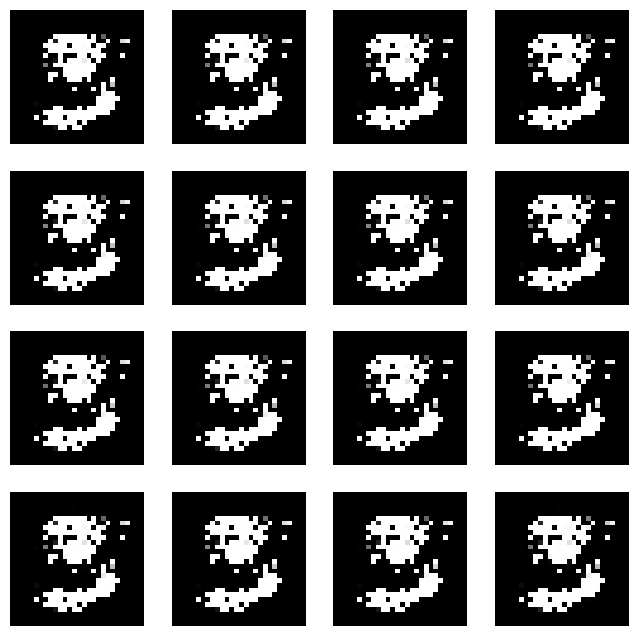

In [8]:
z = torch.randn(16,100).to(device)

fake = generator(z).detach().cpu()

plt.figure(figsize=(8,8))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(
        fake[i,0],
        cmap="gray"
    )

    plt.axis("off")

plt.show()

Plot Loss

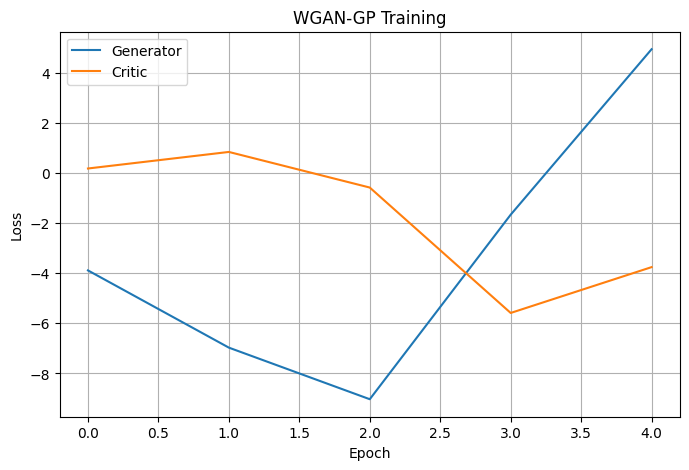

In [9]:
plt.figure(figsize=(8,5))

plt.plot(g_losses,label="Generator")

plt.plot(c_losses,label="Critic")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("WGAN-GP Training")

plt.legend()

plt.grid(True)

plt.show()